# Acoustic Echo Cancellation (AEC)
## Normalized Least Mean Squares (NLMS) Adaptive Filtering & Double-Talk Detection (DTD)

**Author**: Daniel Pereira Riquelme  
**Subject**: Digital Signal Processing (DSP) & Adaptive Filtering

---

### 1. Introduction & Physical Signal Model
Acoustic echo occurs in hands-free telecommunication systems when sound emitted by a loudspeaker is reflected across room boundaries and captured by the near-end microphone:

$$s[n] = x[n] + y[n] = x[n] + (h * u)[n]$$

where:
- $x[n]$: Clean near-end desired speech (`data/local.wav`)
- $u[n]$: Far-end reference signal emitted by loudspeaker (`data/remota.wav`)
- $y[n]$: Acoustic echo arriving at microphone
- $s[n]$: Contaminated microphone pickup (`data/signal.wav`)

The adaptive filter synthesizes an echo replica $\hat{y}[n] = \mathbf{w}^T[n] \mathbf{u}[n]$ and subtracts it, yielding the cleaned speech signal $e[n] = s[n] - \hat{y}[n]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import freqz
from IPython.display import Audio, display

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Load audio WAV files (8 kHz, 16-bit PCM)
fs, local = wavfile.read('data/local.wav')
_, remota = wavfile.read('data/remota.wav')
_, signal_mic = wavfile.read('data/signal.wav')

local = local.astype(np.float64)
remota = remota.astype(np.float64)
signal_mic = signal_mic.astype(np.float64)
n_samples = len(signal_mic)
time_axis = np.arange(n_samples) / fs

print(f'Sampling Rate: {fs} Hz | Duration: {time_axis[-1]:.3f} s ({n_samples} samples)')

Sampling Rate: 8000 Hz | Duration: 1.996 s (15970 samples)


### 2. Audio Listeners (Raw Input Signals)
Listen to the raw audio signals before adaptive filtering:

In [2]:
print('1. Clean Ground Truth Near-End Speech x[n]:')
display(Audio(local, rate=fs))

print('2. Far-End Reference Speech u[n] (Echo Source):')
display(Audio(remota, rate=fs))

print('3. Contaminated Microphone Signal s[n] = x[n] + y[n]:')
display(Audio(signal_mic, rate=fs))

1. Clean Ground Truth Near-End Speech x[n]:


2. Far-End Reference Speech u[n] (Echo Source):


3. Contaminated Microphone Signal s[n] = x[n] + y[n]:


### 3. Task 1: Baseline Signal-to-Noise Ratio (SNR) without Cancellation
The Signal-to-Noise Ratio relative to clean desired speech $x[n]$ is defined as:

$$\text{SNR} = 10 \log_{10}\left(\frac{\sum_{n} x^2[n]}{\sum_{n} (y_{\text{out}}[n] - x[n])^2}\right)$$

Without cancellation ($y_{\text{out}}[n] = s[n]$), distortion is the raw acoustic echo $d[n] = s[n] - x[n]$.

In [3]:
def compute_snr(clean_signal: np.ndarray, distortion: np.ndarray) -> float:
    return 10.0 * np.log10(np.sum(clean_signal**2) / np.sum(distortion**2))

raw_distortion = signal_mic - local
snr_raw = compute_snr(local, raw_distortion)
print(f'Baseline Unprocessed SNR: {snr_raw:.2f} dB')

Baseline Unprocessed SNR: 7.74 dB


### 4. Task 2: Standard NLMS Adaptive Filter Optimization
The Normalized Least Mean Squares (NLMS) update rule normalizes the gradient step by the instantaneous regressor energy:

$$\mathbf{w}[n+1] = \mathbf{w}[n] + \frac{\mu}{\|\mathbf{u}[n]\|^2 + \epsilon} e[n] \mathbf{u}[n]$$

We perform a 2D parameter sweep over step size $\mu \in [0.0005, 0.128]$ and filter order $p \in [2, 7]$.

In [4]:
def run_nlms(u_far, s_mic, mu, p, dtd_sample=None):
    N = len(s_mic)
    w = np.zeros(p, dtype=np.float64)
    buf = np.zeros(p, dtype=np.float64)
    e = np.zeros(N, dtype=np.float64)
    w_hist = np.zeros((N, p), dtype=np.float64)
    eps = 1e-8
    
    for n in range(N):
        buf[1:] = buf[:-1]
        buf[0] = u_far[n]
        y_hat = np.dot(w, buf)
        e[n] = s_mic[n] - y_hat
        
        if dtd_sample is None or n < dtd_sample:
            pwr = np.dot(buf, buf) + eps
            w += (mu * e[n] / pwr) * buf
        w_hist[n, :] = w
        
    return e, w_hist

u_vec = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, 0.128]
p_vec = [2, 3, 4, 5, 6, 7]

best_snr_no_dtd = -np.inf
u_opt_no_dtd, p_opt_no_dtd = 0, 0
w_opt_no_dtd, e_opt_no_dtd = None, None
snr_no_dtd_matrix = np.zeros((len(u_vec), len(p_vec)))

for i, u in enumerate(u_vec):
    for j, p in enumerate(p_vec):
        e, w_hist = run_nlms(remota, signal_mic, u, p, dtd_sample=None)
        snr = compute_snr(local, e - local)
        snr_no_dtd_matrix[i, j] = snr
        if snr > best_snr_no_dtd:
            best_snr_no_dtd = snr
            u_opt_no_dtd, p_opt_no_dtd = u, p
            w_opt_no_dtd, e_opt_no_dtd = w_hist, e

print(f'Standard NLMS Optimum: mu = {u_opt_no_dtd}, p = {p_opt_no_dtd} -> Output SNR = {best_snr_no_dtd:.2f} dB (Gain: +{best_snr_no_dtd - snr_raw:.2f} dB)')

Standard NLMS Optimum: mu = 0.0005, p = 6 -> Output SNR = 15.13 dB (Gain: +7.39 dB)


### 5. Task 3: Double-Talk Detection (DTD) Integration
When the near-end speaker is active ($n \ge 2150$), $x[n]$ acts as large uncorrelated noise to the NLMS filter. Continuing adaptation causes the filter taps to corrupt and distort the local speech.

By freezing adaptation at $n = 2150$ (ideal DTD trigger), we preserve the converged acoustic echo estimate.

In [5]:
dtd_index = 2150
best_snr_dtd = -np.inf
u_opt_dtd, p_opt_dtd = 0, 0
w_opt_dtd, e_opt_dtd = None, None
snr_dtd_matrix = np.zeros((len(u_vec), len(p_vec)))

for i, u in enumerate(u_vec):
    for j, p in enumerate(p_vec):
        e, w_hist = run_nlms(remota, signal_mic, u, p, dtd_sample=dtd_index)
        snr = compute_snr(local, e - local)
        snr_dtd_matrix[i, j] = snr
        if snr > best_snr_dtd:
            best_snr_dtd = snr
            u_opt_dtd, p_opt_dtd = u, p
            w_opt_dtd, e_opt_dtd = w_hist, e

print(f'DTD-Gated NLMS Optimum: mu = {u_opt_dtd}, p = {p_opt_dtd} -> Output SNR = {best_snr_dtd:.2f} dB (Gain: +{best_snr_dtd - snr_raw:.2f} dB)')

DTD-Gated NLMS Optimum: mu = 0.016, p = 5 -> Output SNR = 47.87 dB (Gain: +40.13 dB)


### 6. Visual Performance & Coefficient Evolution Plots
Comparison between Standard NLMS tap divergence and DTD-Gated stabilization:

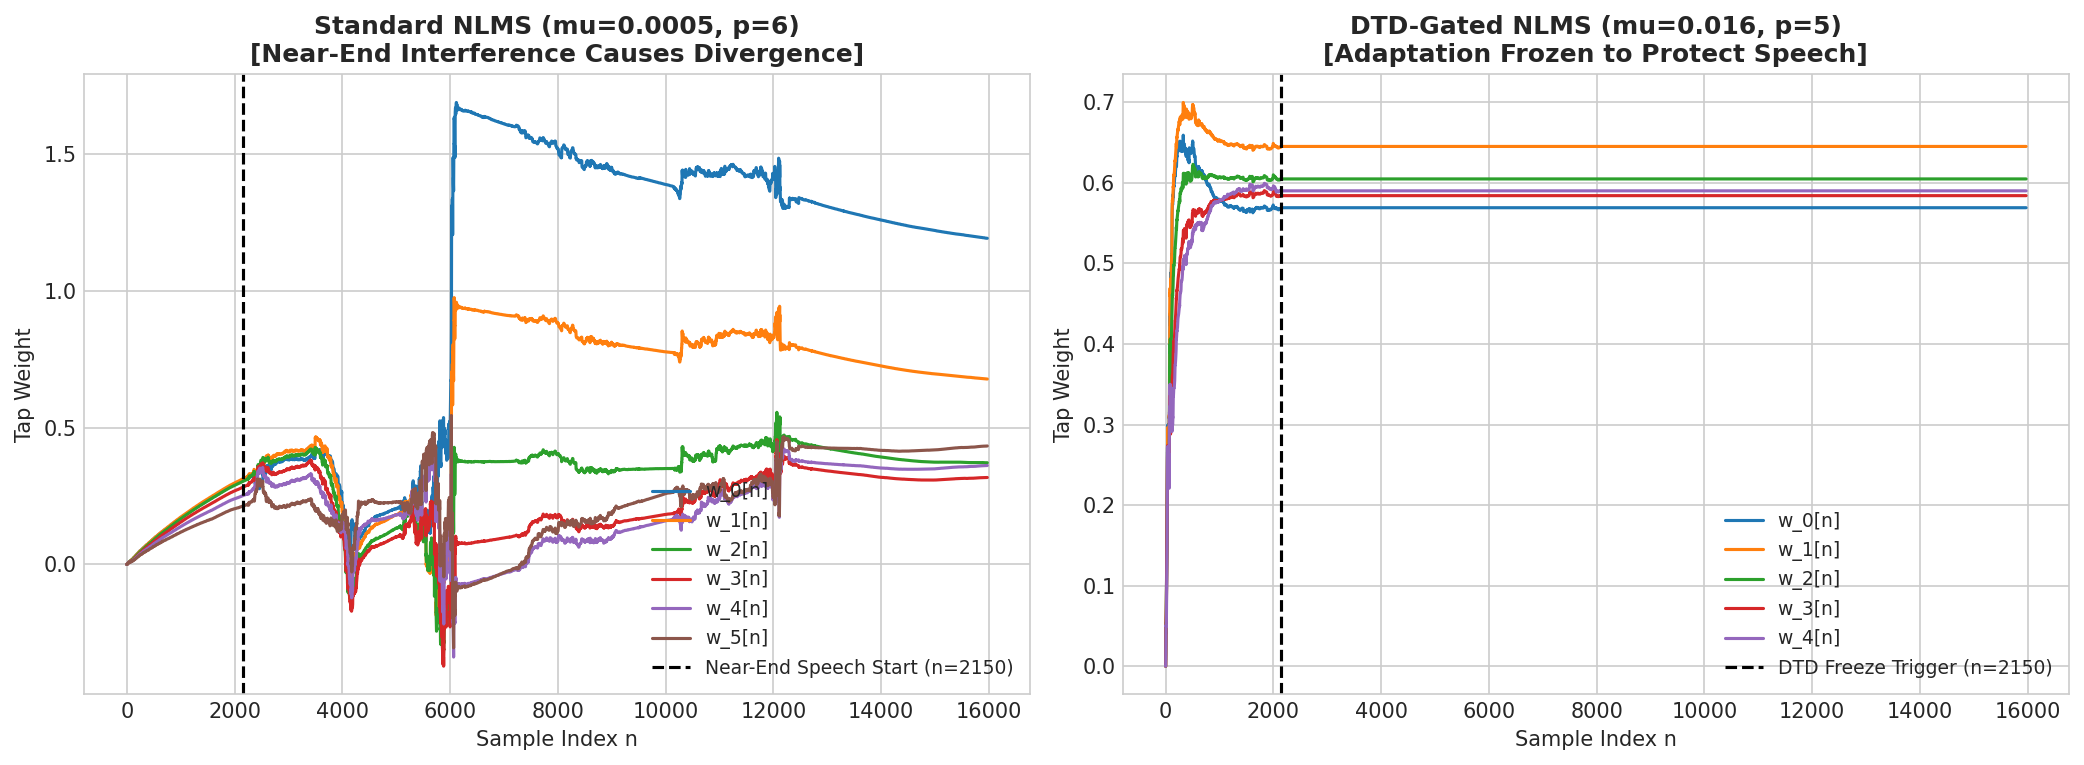

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), dpi=150)
for k in range(p_opt_no_dtd):
    ax1.plot(w_opt_no_dtd[:, k], label=f'w_{k}[n]')
ax1.axvline(dtd_index, color='black', linestyle='--', label=f'Near-End Speech Start (n={dtd_index})')
ax1.set_title(f'Standard NLMS (mu={u_opt_no_dtd}, p={p_opt_no_dtd})\n[Near-End Interference Causes Divergence]', fontweight='bold')
ax1.set_xlabel('Sample Index n')
ax1.set_ylabel('Tap Weight')
ax1.legend(loc='lower right', fontsize=9)

for k in range(p_opt_dtd):
    ax2.plot(w_opt_dtd[:, k], label=f'w_{k}[n]')
ax2.axvline(dtd_index, color='black', linestyle='--', label=f'DTD Freeze Trigger (n={dtd_index})')
ax2.set_title(f'DTD-Gated NLMS (mu={u_opt_dtd}, p={p_opt_dtd})\n[Adaptation Frozen to Protect Speech]', fontweight='bold')
ax2.set_xlabel('Sample Index n')
ax2.set_ylabel('Tap Weight')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

### 7. Frequency & Phase Response of the Room Acoustic Channel
The converged filter weights $\mathbf{w}[2150]$ estimate the unknown transfer function of the room coupling and speaker-microphone enclosure:

<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_968657/938746859.py:8: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_title(f'Estimated Acoustic Channel Magnitude Response |H(e^{{j\omega}})| (FIR p={p_opt_dtd})', fontweight='bold')


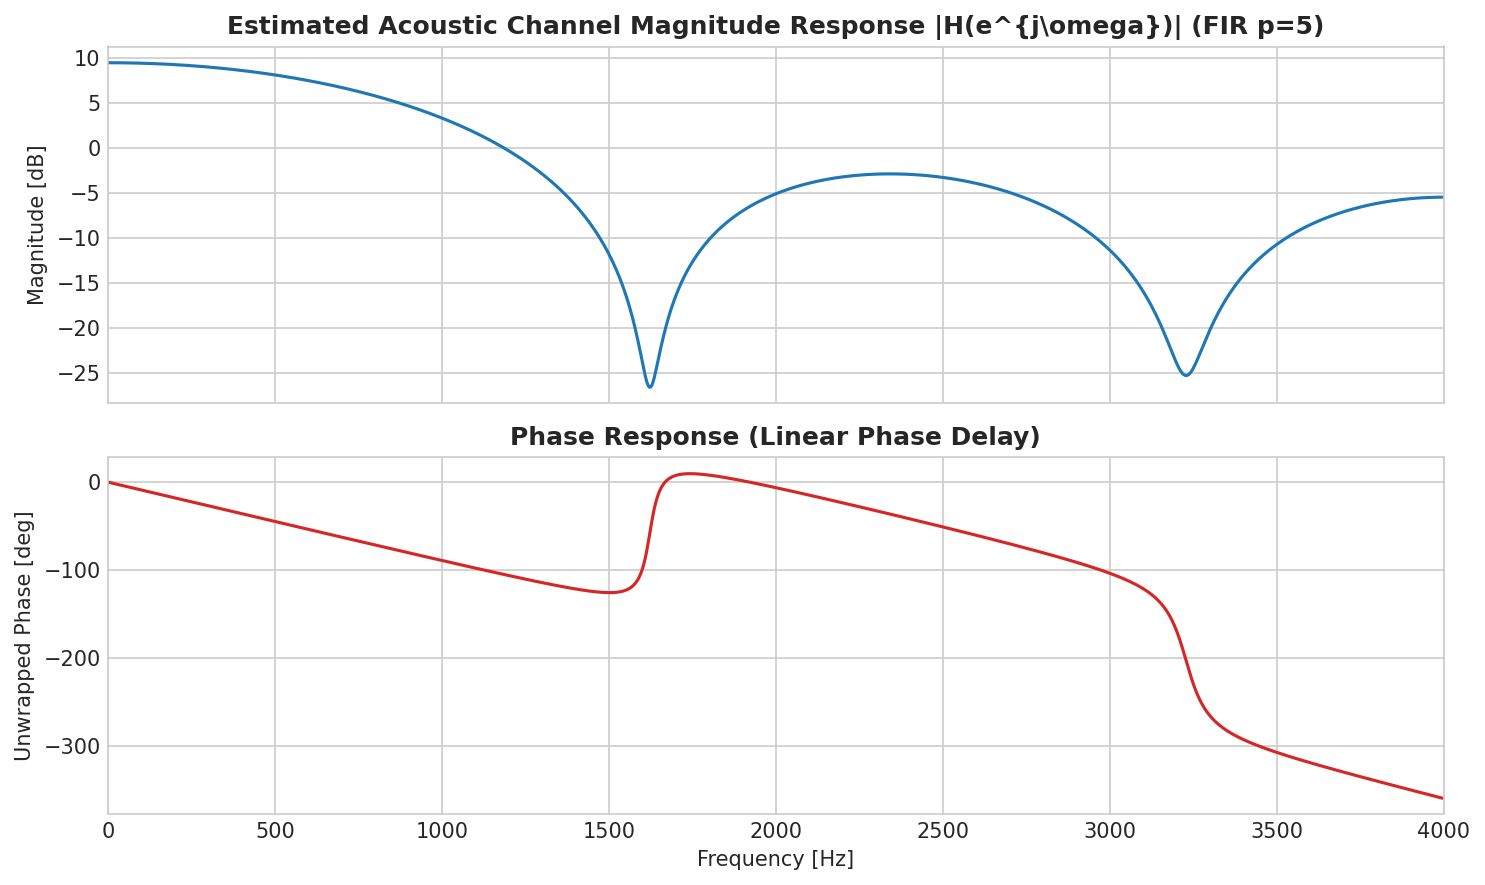

In [7]:
w_final = w_opt_dtd[dtd_index, :]
w_rad, h = freqz(b=w_final, a=1, worN=1024, fs=fs)
h_db = 20 * np.log10(np.abs(h) + 1e-12)
phase_deg = np.unwrap(np.angle(h)) * 180 / np.pi

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, dpi=150)
ax1.plot(w_rad, h_db, color='#1f77b4', linewidth=1.5)
ax1.set_title(f'Estimated Acoustic Channel Magnitude Response |H(e^{{j\omega}})| (FIR p={p_opt_dtd})', fontweight='bold')
ax1.set_ylabel('Magnitude [dB]')
ax1.grid(True)

ax2.plot(w_rad, phase_deg, color='#d62728', linewidth=1.5)
ax2.set_title('Phase Response (Linear Phase Delay)', fontweight='bold')
ax2.set_ylabel('Unwrapped Phase [deg]')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_xlim([0, fs / 2])
ax2.grid(True)

plt.tight_layout()
plt.show()

### 8. Processed Audio Playback
Listen to the results to evaluate the acoustic echo cancellation performance:

In [8]:
print('1. Standard NLMS Output (15.13 dB SNR):')
display(Audio(e_opt_no_dtd, rate=fs))

print('2. DTD-Gated NLMS Output (47.87 dB SNR - Echo Completely Suppressed):')
display(Audio(e_opt_dtd, rate=fs))

print('3. Clean Ground Truth Reference:')
display(Audio(local, rate=fs))

1. Standard NLMS Output (15.13 dB SNR):


2. DTD-Gated NLMS Output (47.87 dB SNR - Echo Completely Suppressed):


3. Clean Ground Truth Reference:
